<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/03.Chapter3%3Avectors-pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Vectors, Part 2
## *Practical Linear Algebra for Data Science* — Mike X Cohen

Chapter 2 introduced vectors as ordered lists of numbers and covered arithmetic, the dot product, and orthogonal decomposition. This chapter moves from *what vectors are* to *what vectors can do together*. We explore a tightly connected chain of concepts:

$$
\text{Vector Sets}
\;\longrightarrow\;
\text{Linear Weighted Combinations}
\;\longrightarrow\;
\text{Linear Independence}
\;\longrightarrow\;
\text{Span \& Subspace}
\;\longrightarrow\;
\text{Basis}
$$

Each link depends on the previous one, and together they form the conceptual backbone of nearly everything that follows in the book -- matrix rank, least squares, PCA, SVD, and more.

**What we will cover:**

1. Vector sets -- collecting vectors into mathematical bags
2. Linear weighted combinations -- the single most important operation in linear algebra
3. Linear independence -- when vectors carry genuinely new information
4. Subspace and span -- the infinite reach of a finite set of vectors
5. Basis -- the rulers we use to measure spaces, and why choosing the right rulers matters for data science

## 0. Setup

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (7, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready. All subsequent cells assume NumPy is imported as `np` and Matplotlib as `plt`.

## 1. Vector Sets

A **vector set** is simply a collection of vectors, denoted with a capital italic letter:

$$
V = \{\mathbf{v}_1,\; \mathbf{v}_2,\; \ldots,\; \mathbf{v}_n\}
$$

Think of it as putting vectors into a bag. The set can be **finite** (e.g., 100 country-level Covid data vectors, each in $\mathbb{R}^3$), **infinite** (e.g., a subspace), or **empty** ($V = \{\}$, which arises in matrix null spaces).

In Python, we typically represent a finite vector set as a list of arrays or as columns (or rows) of a matrix. Below we create a set of three vectors in $\mathbb{R}^4$, stored both ways.

In [6]:
# A vector set: three vectors in R^4
v1 = np.array([8, -4, 14, 6])
v2 = np.array([4, 6, 0, 3])
v3 = np.array([14, 2, 4, 7])

# As a list
S_list = [v1, v2, v3]
print('Vector set as list of arrays:')
for i, v in enumerate(S_list, 1):
    print(f'  v{i} = {v}')

# As a matrix (each vector is a column)
S_matrix = np.column_stack(S_list)
print(f'\nVector set as matrix (columns):\n{S_matrix}')
print(f'Shape: {S_matrix.shape}  ({S_matrix.shape[0]}D vectors, {S_matrix.shape[1]} of them)')

Vector set as list of arrays:
  v1 = [ 8 -4 14  6]
  v2 = [4 6 0 3]
  v3 = [14  2  4  7]

Vector set as matrix (columns):
[[ 8  4 14]
 [-4  6  2]
 [14  0  4]
 [ 6  3  7]]
Shape: (4, 3)  (4D vectors, 3 of them)


We stored three vectors in $\mathbb{R}^4$ both as a Python list `[v1, v2, v3]` and as a $(4 \times 3)$ matrix where each column is a vector. The matrix representation is far more common in practice because it enables efficient linear algebra via `np.linalg` routines.

**Production insight:** In data science, a dataset *is* a vector set. Each row of your data frame is a feature vector $\mathbf{x}_i \in \mathbb{R}^p$, and the entire dataset is the set $\{\mathbf{x}_1, \ldots, \mathbf{x}_n\}$. When stored as a matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$, every column represents a variable and every row a sample. The concepts in this chapter -- independence, span, basis -- tell us about the *structure* of that dataset.

## 2. Linear Weighted Combination

A **linear weighted combination** (also called a linear combination or linear mixture) takes a set of vectors, multiplies each by a scalar weight, and sums the results:

$$
\mathbf{w} = \lambda_1 \mathbf{v}_1 + \lambda_2 \mathbf{v}_2 + \cdots + \lambda_n \mathbf{v}_n = \sum_{i=1}^{n} \lambda_i \mathbf{v}_i
$$

The $\lambda_i$ are real-valued scalars (sometimes called **weights** or **coefficients**). All vectors must share the same dimensionality. This deceptively simple operation is the single most important building block in linear algebra -- it directly underpins regression, PCA, neural networks, and almost every other technique in applied linear algebra.

In [7]:
# Textbook example (Equation 3-2)
l1, l2, l3 = 1, 2, -3
v1 = np.array([4, 5, 1])
v2 = np.array([-4, 0, -4])
v3 = np.array([1, 3, 2])

w = l1*v1 + l2*v2 + l3*v3

print(f'lambda_1 = {l1},  v1 = {v1}')
print(f'lambda_2 = {l2},  v2 = {v2}')
print(f'lambda_3 = {l3},  v3 = {v3}')
print(f'\nw = {l1}*v1 + {l2}*v2 + ({l3})*v3 = {w}')

# Step-by-step
print(f'\nStep by step:')
print(f'  {l1}*v1 = {l1*v1}')
print(f'  {l2}*v2 = {l2*v2}')
print(f'  {l3}*v3 = {l3*v3}')
print(f'  Sum     = {l1*v1 + l2*v2 + l3*v3}')

lambda_1 = 1,  v1 = [4 5 1]
lambda_2 = 2,  v2 = [-4  0 -4]
lambda_3 = -3,  v3 = [1 3 2]

w = 1*v1 + 2*v2 + (-3)*v3 = [ -7  -4 -13]

Step by step:
  1*v1 = [4 5 1]
  2*v2 = [-8  0 -8]
  -3*v3 = [-3 -9 -6]
  Sum     = [ -7  -4 -13]


The linear weighted combination produces $\mathbf{w} = [-7, -4, -13]^T$, matching the textbook. Step by step:

$$
\mathbf{w} = 1 \begin{bmatrix} 4 \\ 5 \\ 1 \end{bmatrix}
+ 2 \begin{bmatrix} -4 \\ 0 \\ -4 \end{bmatrix}
+ (-3) \begin{bmatrix} 1 \\ 3 \\ 2 \end{bmatrix}
= \begin{bmatrix} 4 \\ 5 \\ 1 \end{bmatrix}
+ \begin{bmatrix} -8 \\ 0 \\ -8 \end{bmatrix}
+ \begin{bmatrix} -3 \\ -9 \\ -6 \end{bmatrix}
= \begin{bmatrix} -7 \\ -4 \\ -13 \end{bmatrix}
$$

**Three applications the textbook highlights** (each a linear weighted combination in disguise):

1. **Statistical models (Chapters 11--12):** The prediction $\hat{y} = \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$ is a linear weighted combination of regressors $x_j$ with learned coefficients $\beta_j$.

2. **PCA (Chapter 15):** Each principal component is a linear weighted combination of the original data channels, with weights chosen to maximise variance.

3. **Neural networks:** Each layer computes $\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$ (a linear combination) followed by a nonlinear activation $\sigma(\mathbf{z})$. The weights $\mathbf{W}$ are learned by minimising a loss function.

### 2.1 Visualising Linear Combinations in 2D

To build geometric intuition, let's see how two basis vectors in $\mathbb{R}^2$ can be combined with different weights to produce new vectors.

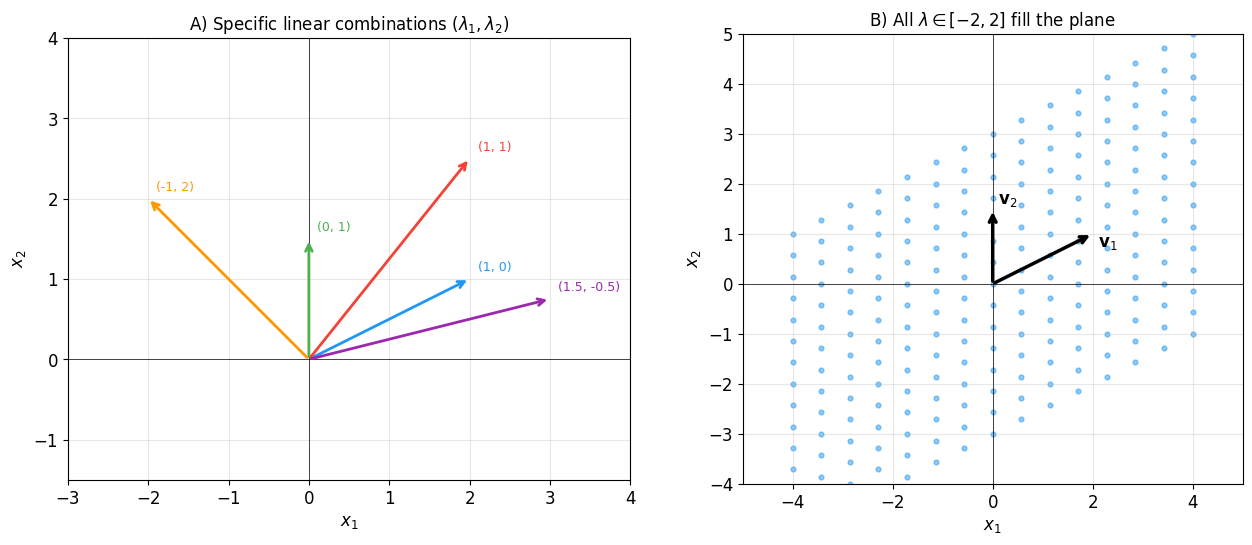

Figure saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

v1 = np.array([2, 1])
v2 = np.array([0, 1.5])

# Panel A: Show several specific combinations
ax = axes[0]
combos = [
    (1, 0, '#2196F3'),
    (0, 1, '#4CAF50'),
    (1, 1, '#F44336'),
    (1.5, -0.5, '#9C27B0'),
    (-1, 2, '#FF9800'),
]
for (a, b, c) in combos:
    w = a*v1 + b*v2
    ax.annotate('', xy=w, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.text(w[0]+0.1, w[1]+0.1, f'({a}, {b})', fontsize=9, color=c)

ax.set_xlim(-3, 4)
ax.set_ylim(-1.5, 4)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('A) Specific linear combinations $(\\lambda_1, \\lambda_2)$', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Panel B: Grid of combinations -> they fill the plane
ax = axes[1]
lambdas = np.linspace(-2, 2, 15)
points = []
for a in lambdas:
    for b in lambdas:
        w = a*v1 + b*v2
        points.append(w)
points = np.array(points)
ax.scatter(points[:, 0], points[:, 1], s=12, c='#2196F3', alpha=0.5)

# Show the two basis vectors
ax.annotate('', xy=v1, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
ax.annotate('', xy=v2, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
ax.text(v1[0]+0.1, v1[1]-0.25, '$\mathbf{v}_1$', fontsize=12, fontweight='bold')
ax.text(v2[0]+0.1, v2[1]+0.1, '$\mathbf{v}_2$', fontsize=12, fontweight='bold')

ax.set_xlim(-5, 5)
ax.set_ylim(-4, 5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('B) All $\\lambda \\in [-2, 2]$ fill the plane', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('fig_lin_combo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Panel A shows five specific combinations of $\mathbf{v}_1 = [2, 1]^T$ and $\mathbf{v}_2 = [0, 1.5]^T$ with different weight pairs $(\lambda_1, \lambda_2)$. Each pair of weights produces a different vector.

Panel B samples $\lambda_1, \lambda_2 \in [-2, 2]$ on a grid and plots all resulting vectors. Even with this limited range, the points fill a region of $\mathbb{R}^2$. If we extended the range to $(-\infty, +\infty)$, every point in the plane would be reachable. This is the essence of **span**: two linearly independent vectors in $\mathbb{R}^2$ can reach any point in $\mathbb{R}^2$.

**Key principle:** Linear weighted combinations are the *mechanism* that creates subspaces. The specific weights $\lambda_i$ select one point in the subspace; the totality of all possible weights defines the entire subspace.

## 3. Linear Independence

A set of vectors is **linearly dependent** if at least one vector can be expressed as a linear weighted combination of the others. The set is **linearly independent** if *no* such combination exists.

Think of it this way: each independent vector carries genuinely *new* information that the other vectors do not. A dependent vector is redundant -- it is already "reachable" from the others.

### 3.1 Simple Examples by Inspection

In [9]:
# Set V: independent
V = [np.array([1, 3]), np.array([2, 7])]
print('Set V:')
for i, v in enumerate(V, 1):
    print(f'  v{i} = {v}')

# Can v1 = lambda * v2? That requires 1/2 = 3/7 -> 7 != 6. No!
ratio_check = V[0][0] / V[1][0], V[0][1] / V[1][1]
print(f'  Ratio check: {V[0][0]}/{V[1][0]} = {ratio_check[0]:.4f}, '
      f'{V[0][1]}/{V[1][1]} = {ratio_check[1]:.4f}')
print(f'  Ratios differ -> V is INDEPENDENT\n')

# Set S: dependent
S = [np.array([1, 3]), np.array([2, 6])]
print('Set S:')
for i, s in enumerate(S, 1):
    print(f'  s{i} = {s}')

ratio_check2 = S[0][0] / S[1][0], S[0][1] / S[1][1]
print(f'  Ratio check: {S[0][0]}/{S[1][0]} = {ratio_check2[0]:.4f}, '
      f'{S[0][1]}/{S[1][1]} = {ratio_check2[1]:.4f}')
print(f'  Ratios equal -> S is DEPENDENT (s2 = 2*s1)')

Set V:
  v1 = [1 3]
  v2 = [2 7]
  Ratio check: 1/2 = 0.5000, 3/7 = 0.4286
  Ratios differ -> V is INDEPENDENT

Set S:
  s1 = [1 3]
  s2 = [2 6]
  Ratio check: 1/2 = 0.5000, 3/6 = 0.5000
  Ratios equal -> S is DEPENDENT (s2 = 2*s1)


For a two-vector set in $\mathbb{R}^2$, the independence check is straightforward: if one vector is a scalar multiple of the other, the set is dependent. In set $V$, the element-wise ratios are $1/2 = 0.5$ and $3/7 \approx 0.4286$ -- they differ, so no single $\lambda$ satisfies $\mathbf{v}_1 = \lambda \mathbf{v}_2$. The set is **independent**.

In set $S$, both ratios are $0.5$, meaning $\mathbf{s}_1 = 0.5 \cdot \mathbf{s}_2$ (equivalently, $\mathbf{s}_2 = 2 \cdot \mathbf{s}_1$). The set is **dependent** -- one vector is completely redundant.

**Geometric interpretation:** Independent vectors point in genuinely different directions (they are not collinear). Dependent vectors are collinear -- they lie on the same line through the origin.

### 3.2 A Harder Example

The textbook presents a four-vector set in $\mathbb{R}^4$ where independence is impossible to determine by visual inspection. The systematic approach uses **matrix rank** (Chapter 6), but we can preview it here.

In [10]:
# Textbook set T: four vectors in R^4
t1 = np.array([8, -4, 14, 6])
t2 = np.array([4, 6, 0, 3])
t3 = np.array([14, 2, 4, 7])
t4 = np.array([13, 2, 9, 8])

T = np.column_stack([t1, t2, t3, t4])
print(f'Matrix T (columns are vectors):')
print(T)
print(f'Shape: {T.shape}')

rank = np.linalg.matrix_rank(T)
print(f'\nRank of T: {rank}')
print(f'Number of vectors: {T.shape[1]}')
print(f'Rank < number of vectors -> set is DEPENDENT')

# The textbook hint: t1 + t2 + t3 = 2*t4
print(f'\nVerification: t1 + t2 + t3 = {t1 + t2 + t3}')
print(f'              2 * t4       = {2 * t4}')
print(f'              Equal? {np.array_equal(t1 + t2 + t3, 2 * t4)}')

Matrix T (columns are vectors):
[[ 8  4 14 13]
 [-4  6  2  2]
 [14  0  4  9]
 [ 6  3  7  8]]
Shape: (4, 4)

Rank of T: 3
Number of vectors: 4
Rank < number of vectors -> set is DEPENDENT

Verification: t1 + t2 + t3 = [26  4 18 16]
              2 * t4       = [26  4 18 16]
              Equal? True


The matrix formed by stacking the four vectors as columns has **rank 3**, which is less than the 4 vectors in the set. This confirms **linear dependence**.

The specific dependency is $\mathbf{t}_1 + \mathbf{t}_2 + \mathbf{t}_3 = 2\mathbf{t}_4$, or equivalently:

$$
1 \cdot \mathbf{t}_1 + 1 \cdot \mathbf{t}_2 + 1 \cdot \mathbf{t}_3 + (-2) \cdot \mathbf{t}_4 = \mathbf{0}
$$

This is exactly the form of the **formal definition of linear dependence** (Equation 3-3): a nontrivial combination of the vectors equals the zeros vector, with $\lambda_1 = 1, \lambda_2 = 1, \lambda_3 = 1, \lambda_4 = -2$ (all nonzero).

**The general rule** (fully explained in Chapter 6): form a matrix from the vectors, compute its rank, and compare to the number of vectors. If rank $<$ number of vectors, the set is dependent. If rank $=$ number of vectors, the set is independent.

### 3.3 The Formal Definition of Linear Independence

A set $\{\mathbf{v}_1, \ldots, \mathbf{v}_n\}$ is **linearly dependent** if there exist scalars $\lambda_1, \ldots, \lambda_n$, *not all zero*, such that:

$$
\lambda_1 \mathbf{v}_1 + \lambda_2 \mathbf{v}_2 + \cdots + \lambda_n \mathbf{v}_n = \mathbf{0}
$$

The set is **linearly independent** if the *only* solution is the trivial one: $\lambda_1 = \lambda_2 = \cdots = \lambda_n = 0$.

**Why set equal to zero?** Setting the equation to $\mathbf{0}$ (rather than isolating one vector on the left) emphasises that independence is a property of the *entire set*, not of any individual vector. No vector holds a privileged "dependent" position.

**Special case -- the zeros vector:** Any set containing $\mathbf{0}$ is automatically dependent, because $\lambda_0 \cdot \mathbf{0} + 0 \cdot \mathbf{v}_1 + \cdots = \mathbf{0}$ for any $\lambda_0 \neq 0$.

In [11]:
# Demonstrate: any set containing the zeros vector is dependent
z = np.zeros(3)
v = np.array([1, 2, 3])

# lambda_0 * 0 + 0 * v = 0  for any lambda_0 != 0
lam0 = 42  # any nonzero value works
result = lam0 * z + 0 * v
print(f'zeros vector: {z}')
print(f'v = {v}')
print(f'{lam0} * zeros + 0 * v = {result}')
print(f'Equals zero vector? {np.allclose(result, 0)}')
print(f'At least one lambda != 0? Yes (lambda_0 = {lam0})')
print(f'Therefore the set {{0, v}} is DEPENDENT.')

zeros vector: [0. 0. 0.]
v = [1 2 3]
42 * zeros + 0 * v = [0. 0. 0.]
Equals zero vector? True
At least one lambda != 0? Yes (lambda_0 = 42)
Therefore the set {0, v} is DEPENDENT.


With $\lambda_0 = 42$ (any nonzero scalar works) and $\lambda_1 = 0$, the combination $42 \cdot \mathbf{0} + 0 \cdot \mathbf{v} = \mathbf{0}$ is satisfied. Since at least one $\lambda \neq 0$, the definition of dependence is met. The zeros vector acts as an automatic "free pass" for dependence -- it contributes nothing to the span of the set.

**Practical implication:** If your feature matrix contains a column of all zeros (a variable with no variance), that column is guaranteed to be linearly dependent on the others. This causes rank deficiency, which breaks ordinary least squares. Many libraries (e.g., `statsmodels`, `sklearn`) handle this by silently dropping the zero column or using a pseudoinverse.

### 3.4 Visualising Independence vs. Dependence

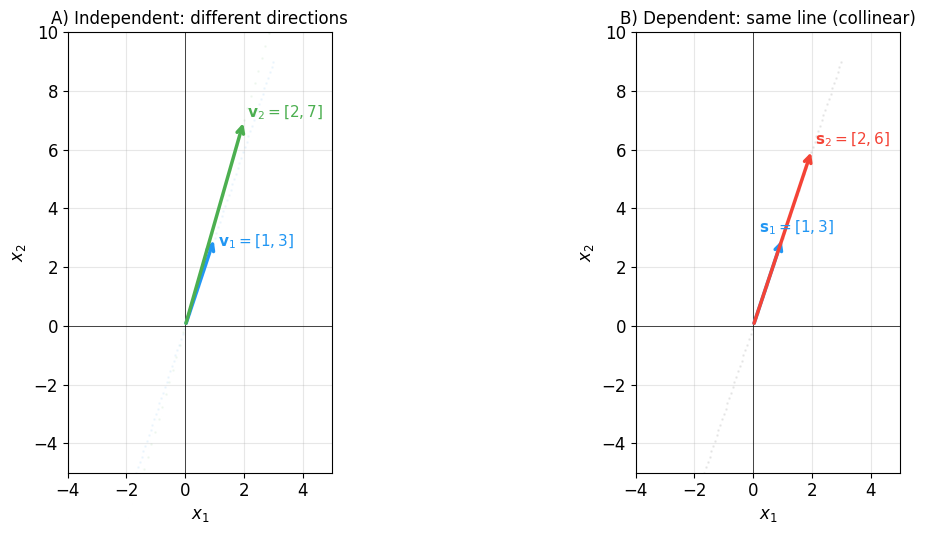

Figure saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel A: Independent set
ax = axes[0]
v1 = np.array([1, 3])
v2 = np.array([2, 7])

ax.annotate('', xy=v1, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.annotate('', xy=v2, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.text(v1[0]+0.1, v1[1]-0.3, '$\mathbf{v}_1 = [1,3]$', fontsize=11, color='#2196F3')
ax.text(v2[0]+0.1, v2[1]+0.1, '$\mathbf{v}_2 = [2,7]$', fontsize=11, color='#4CAF50')

# Show extended lines (span directions)
for v, c in [(v1, '#2196F3'), (v2, '#4CAF50')]:
    for s in np.linspace(-3, 3, 100):
        pt = s * v
        ax.plot(pt[0], pt[1], '.', color=c, alpha=0.05, ms=2)

ax.set_xlim(-4, 5)
ax.set_ylim(-5, 10)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('A) Independent: different directions', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Panel B: Dependent set
ax = axes[1]
s1 = np.array([1, 3])
s2 = np.array([2, 6])

ax.annotate('', xy=s1, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.annotate('', xy=s2, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5))
ax.text(s1[0]-0.8, s1[1]+0.2, '$\mathbf{s}_1 = [1,3]$', fontsize=11, color='#2196F3')
ax.text(s2[0]+0.1, s2[1]+0.2, '$\mathbf{s}_2 = [2,6]$', fontsize=11, color='#F44336')

# Show they lie on the same line
for s in np.linspace(-3, 3, 100):
    pt = s * s1
    ax.plot(pt[0], pt[1], '.', color='#9E9E9E', alpha=0.15, ms=2)

ax.set_xlim(-4, 5)
ax.set_ylim(-5, 10)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('B) Dependent: same line (collinear)', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('fig_indep_dep.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Panel A shows two independent vectors that point in **different directions**. Together they can reach any point in $\mathbb{R}^2$ (they span the full plane). Panel B shows a dependent pair: $\mathbf{s}_2 = 2\mathbf{s}_1$, so both vectors lie on the *same line* through the origin. Adding the second vector contributes zero new "reach" -- the span remains a single line.

**Intuition:** Independence means each vector adds a new dimension to the span. Dependence means at least one vector is "already covered" by the others. In data science terms, a dependent feature is a redundant feature -- it provides no information beyond what the other features already encode.

## 4. Subspace and Span

A **subspace** is the infinite set of *all* possible linear weighted combinations of a set of vectors. The process of generating this set is called **spanning**, and the result is the **span** of the vector set.

- Think of **span** as a *verb*: vectors span a subspace.
- Think of **subspace** as a *noun*: the result of spanning.

Formally, a vector subspace must be **closed under addition and scalar multiplication** and must **include the origin** ($\mathbf{0}$). This means: take any two vectors in the subspace, add them or scale them, and the result is still in the subspace. Setting all weights to zero gives $\mathbf{0}$, confirming the origin is included.

### 4.1 Example: One Vector Spans a Line

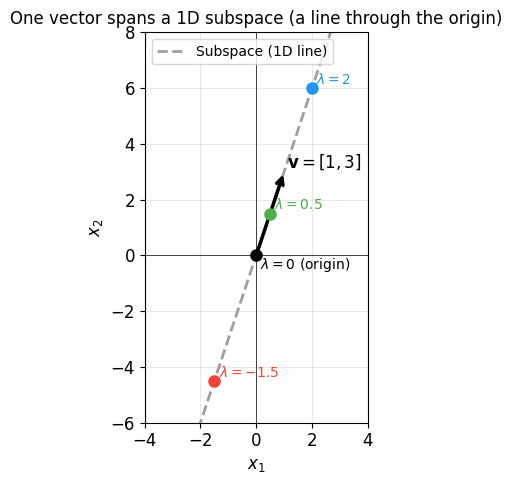

Figure saved.


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

v = np.array([1, 3])

# The subspace: all scalar multiples of v
t_vals = np.linspace(-3, 3, 500)
line = np.outer(t_vals, v)  # shape (500, 2)
ax.plot(line[:, 0], line[:, 1], '--', color='#9E9E9E', lw=2, label='Subspace (1D line)')

# The vector itself
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
ax.text(v[0]+0.1, v[1]+0.15, '$\mathbf{v} = [1, 3]$', fontsize=12)

# Mark some specific scaled versions
for s, c in [(-1.5, '#F44336'), (0.5, '#4CAF50'), (2, '#2196F3')]:
    sv = s * v
    ax.plot(*sv, 'o', color=c, ms=8, zorder=5)
    ax.text(sv[0]+0.15, sv[1]+0.15, f'$\\lambda={s}$', fontsize=10, color=c)

ax.plot(0, 0, 'ko', ms=8, zorder=5)  # origin
ax.text(0.15, -0.5, '$\\lambda=0$ (origin)', fontsize=10)

ax.set_xlim(-4, 4)
ax.set_ylim(-6, 8)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('One vector spans a 1D subspace (a line through the origin)', fontsize=12)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('fig_span_1d.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The single vector $\mathbf{v} = [1, 3]^T$ spans a **1D subspace**: an infinite line through the origin in $\mathbb{R}^2$. Every point on the dashed gray line is $\lambda \mathbf{v}$ for some $\lambda \in \mathbb{R}$. Setting $\lambda = 0$ gives the origin; $\lambda > 0$ extends in the direction of $\mathbf{v}$; $\lambda < 0$ extends in the opposite direction.

This subspace is a *proper* subspace of $\mathbb{R}^2$ -- it does not fill the entire plane. Points off the line (like $[2, 1]^T$) cannot be reached by any scalar multiple of $\mathbf{v}$.

### 4.2 Two Independent Vectors in $\mathbb{R}^3$ Span a Plane

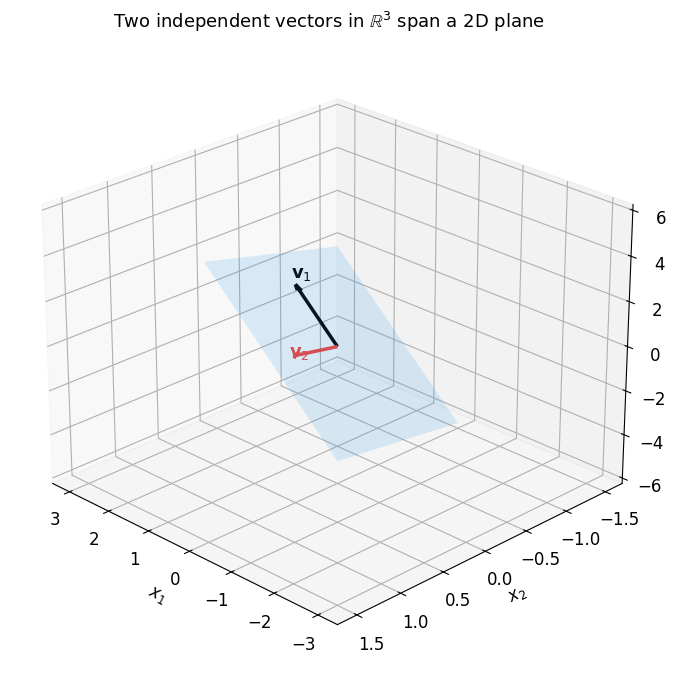

Figure saved.


In [14]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

v1 = np.array([1, 0, 2])
v2 = np.array([-1, 1, 2])

# Create the 2D subspace (plane)
s = np.linspace(-1.5, 1.5, 30)
S1, S2 = np.meshgrid(s, s)
X = S1 * v1[0] + S2 * v2[0]
Y = S1 * v1[1] + S2 * v2[1]
Z = S1 * v1[2] + S2 * v2[2]

ax.plot_surface(X, Y, Z, alpha=0.15, color='#2196F3')

# Plot the vectors
origin = [0, 0, 0]
ax.quiver(*origin, *v1, color='k', arrow_length_ratio=0.1, lw=2.5)
ax.quiver(*origin, *v2, color='#F44336', arrow_length_ratio=0.1, lw=2.5)

ax.text(v1[0]+0.1, v1[1], v1[2]+0.2, '$\mathbf{v}_1$', fontsize=13)
ax.text(v2[0]-0.1, v2[1]+0.1, v2[2]+0.2, '$\mathbf{v}_2$', fontsize=13, color='#F44336')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_title('Two independent vectors in $\\mathbb{R}^3$ span a 2D plane', fontsize=13)
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig('fig_span_2d_in_3d.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Two linearly independent vectors $\mathbf{v}_1 = [1, 0, 2]^T$ and $\mathbf{v}_2 = [-1, 1, 2]^T$ in $\mathbb{R}^3$ span a **2D plane** (the blue translucent surface). This plane passes through the origin and contains every vector of the form $\lambda_1 \mathbf{v}_1 + \lambda_2 \mathbf{v}_2$.

The plane is a proper subspace of $\mathbb{R}^3$ -- points not on the plane (e.g., directly along the $x_2$-axis) are unreachable.

### 4.3 Two Dependent Vectors Span Only a Line

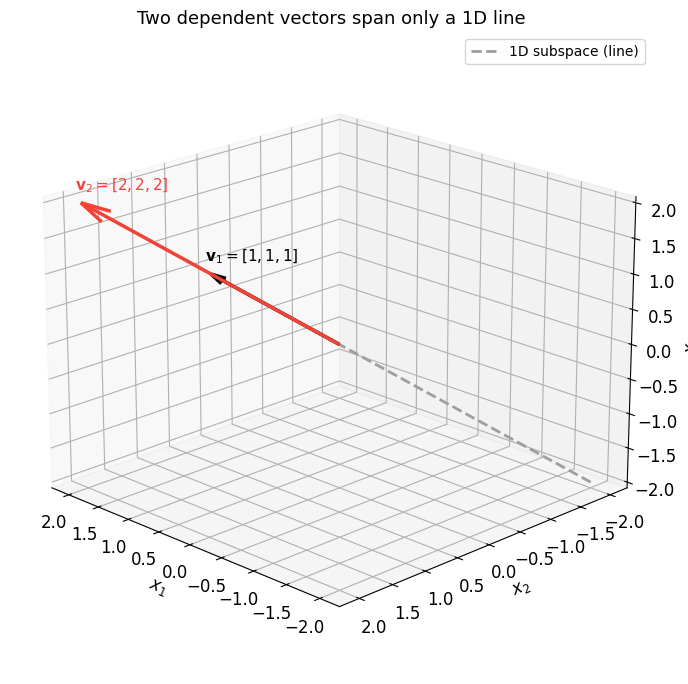

Figure saved.


In [15]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

v1 = np.array([1, 1, 1])
v2 = np.array([2, 2, 2])  # = 2 * v1 -> dependent!

# The subspace is just a line
t = np.linspace(-2, 2, 100)
line = np.outer(t, v1)
ax.plot(line[:, 0], line[:, 1], line[:, 2], '--', color='#9E9E9E', lw=2,
        label='1D subspace (line)')

ax.quiver(*[0,0,0], *v1, color='k', arrow_length_ratio=0.1, lw=2.5)
ax.quiver(*[0,0,0], *v2, color='#F44336', arrow_length_ratio=0.1, lw=2.5)
ax.text(v1[0]+0.1, v1[1], v1[2]+0.15, '$\mathbf{v}_1=[1,1,1]$', fontsize=11)
ax.text(v2[0]+0.1, v2[1], v2[2]+0.15, '$\mathbf{v}_2=[2,2,2]$', fontsize=11, color='#F44336')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_3$')
ax.set_title('Two dependent vectors span only a 1D line', fontsize=13)
ax.legend(fontsize=10)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.savefig('fig_span_dep.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Although we have two vectors in $\mathbb{R}^3$, the set $\{[1,1,1]^T,\; [2,2,2]^T\}$ is **linearly dependent** ($\mathbf{v}_2 = 2\mathbf{v}_1$). The second vector adds no new directions, so the span collapses from an expected 2D plane down to a **1D line**.

This illustrates the key relationship:

$$
\dim(\text{span}(\{\mathbf{v}_1, \ldots, \mathbf{v}_n\})) = \text{number of linearly independent vectors in the set}
$$

For an independent set, the dimension of the spanned subspace equals the number of vectors. For a dependent set, the dimension is strictly *less* than the number of vectors. The exact relationship is formalised by **matrix rank** in Chapter 6.

**Data science connection:** In a dataset with $p$ features, if some features are exact linear combinations of others, the effective dimensionality of the data is less than $p$. This is called **multicollinearity**, and it causes numerical instability in regression. PCA and SVD reveal this by exposing the true rank of the data matrix.

## 5. Basis

A **basis** for a subspace is a set of vectors that:

1. **Spans** the subspace (can reach every point in it), and
2. Is **linearly independent** (no redundancy).

Think of a basis as a set of rulers for measuring a space. The same point can be described using different basis sets (different rulers), but each basis assigns a *unique* coordinate to each point.

### 5.1 The Standard Basis

The most familiar basis is the **Cartesian** or **standard basis**, consisting of unit vectors along each axis:

$$
S_2 = \left\{\begin{bmatrix} 1 \\ 0 \end{bmatrix},\; \begin{bmatrix} 0 \\ 1 \end{bmatrix}\right\}
\qquad\qquad
S_3 = \left\{\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix},\;
\begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix},\;
\begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}\right\}
$$

These vectors are mutually orthogonal and unit length, making them an **orthonormal** basis. This is convenient but not required -- any independent spanning set is a valid basis.

In [16]:
# Standard basis for R^2 and R^3
S2 = [np.array([1, 0]), np.array([0, 1])]
S3 = [np.array([1, 0, 0]), np.array([0, 1, 0]), np.array([0, 0, 1])]

print('Standard basis S2 for R^2:')
for i, v in enumerate(S2, 1):
    print(f'  e{i} = {v}')

print(f'\nStandard basis S3 for R^3:')
for i, v in enumerate(S3, 1):
    print(f'  e{i} = {v}')

# Verify orthonormality for S2
print(f'\nS2 orthogonality: e1 . e2 = {np.dot(S2[0], S2[1])}')
print(f'S2 unit length: ||e1|| = {np.linalg.norm(S2[0])}, ||e2|| = {np.linalg.norm(S2[1])}')

Standard basis S2 for R^2:
  e1 = [1 0]
  e2 = [0 1]

Standard basis S3 for R^3:
  e1 = [1 0 0]
  e2 = [0 1 0]
  e3 = [0 0 1]

S2 orthogonality: e1 . e2 = 0
S2 unit length: ||e1|| = 1.0, ||e2|| = 1.0


The standard basis vectors $\mathbf{e}_1, \mathbf{e}_2$ are orthogonal ($\mathbf{e}_1^T\mathbf{e}_2 = 0$) and unit length ($\|\mathbf{e}_i\| = 1$). Any point $\mathbf{p} = [p_1, p_2]^T$ in $\mathbb{R}^2$ is expressed as $p_1 \mathbf{e}_1 + p_2 \mathbf{e}_2$ -- the Cartesian coordinates are literally the weights in the linear combination.

The standard basis is so natural that we rarely think of coordinates as linear combinations. But every coordinate is secretly a weighted sum of basis vectors. This perspective becomes critical when we switch to a different basis.

### 5.2 An Alternative Basis

The textbook introduces a non-standard basis set for $\mathbb{R}^2$:

$$
T = \left\{\mathbf{t}_1 = \begin{bmatrix} 3 \\ 1 \end{bmatrix},\;
\mathbf{t}_2 = \begin{bmatrix} -3 \\ 1 \end{bmatrix}\right\}
$$

Both $S_2$ and $T$ span all of $\mathbb{R}^2$, but the same data points have different coordinates in each basis. Let's reproduce the textbook's Figure 3-4.

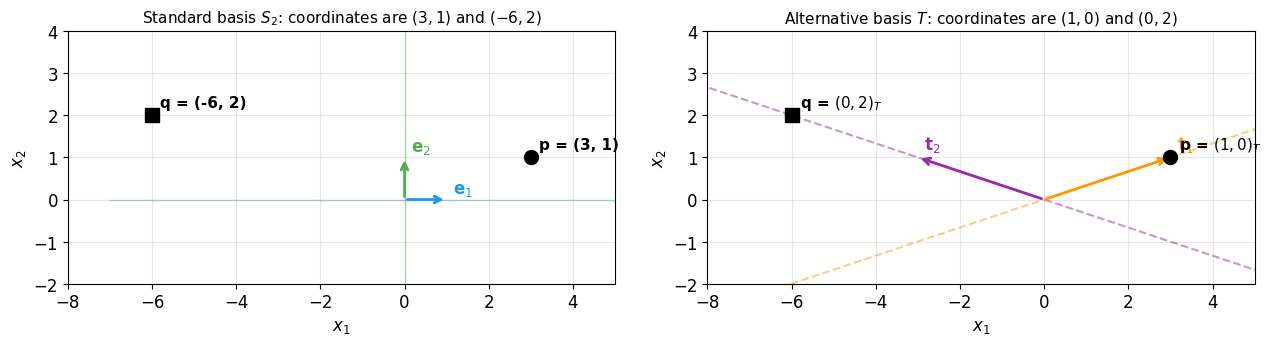

Figure saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Basis vectors
s1, s2 = np.array([1, 0]), np.array([0, 1])  # standard
t1, t2 = np.array([3, 1]), np.array([-3, 1])  # alternative

# Data points
p = np.array([3, 1])
q = np.array([-6, 2])

# --- Panel A: Standard basis ---
ax = axes[0]
for v, label, c in [(s1, '$\mathbf{e}_1$', '#2196F3'), (s2, '$\mathbf{e}_2$', '#4CAF50')]:
    sc = 7
    ax.plot([-sc*v[0], sc*v[0]], [-sc*v[1], sc*v[1]], '-', color=c, lw=1, alpha=0.4)
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.text(v[0]+0.15, v[1]+0.15, label, fontsize=12, color=c)

ax.plot(*p, 'ko', ms=10, zorder=5)
ax.text(p[0]+0.2, p[1]+0.2, f'p = ({p[0]}, {p[1]})', fontsize=11, fontweight='bold')
ax.plot(*q, 'ks', ms=10, zorder=5)
ax.text(q[0]+0.2, q[1]+0.2, f'q = ({q[0]}, {q[1]})', fontsize=11, fontweight='bold')

ax.set_xlim(-8, 5)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
ax.set_title('Standard basis $S_2$: coordinates are $(3,1)$ and $(-6,2)$', fontsize=11)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# --- Panel B: Alternative basis ---
ax = axes[1]
for v, label, c in [(t1, '$\mathbf{t}_1$', '#FF9800'), (t2, '$\mathbf{t}_2$', '#9C27B0')]:
    sc = 3
    ax.plot([-sc*v[0], sc*v[0]], [-sc*v[1], sc*v[1]], '--', color=c, lw=1.5, alpha=0.5)
    ax.annotate('', xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2))
    ax.text(v[0]+0.15, v[1]+0.2, label, fontsize=12, color=c)

ax.plot(*p, 'ko', ms=10, zorder=5)
ax.text(p[0]+0.2, p[1]+0.2, f'p = $(1, 0)_T$', fontsize=11, fontweight='bold')
ax.plot(*q, 'ks', ms=10, zorder=5)
ax.text(q[0]+0.2, q[1]+0.2, f'q = $(0, 2)_T$', fontsize=11, fontweight='bold')

ax.set_xlim(-8, 5)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
ax.set_title('Alternative basis $T$: coordinates are $(1,0)$ and $(0,2)$', fontsize=11)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('fig_basis_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The same points $p$ and $q$ have different coordinates in each basis:

| Point | Standard basis $S_2$ | Alternative basis $T$ |
|:---:|:---:|:---:|
| $p$ | $(3, 1)$ i.e. $3\mathbf{e}_1 + 1\mathbf{e}_2$ | $(1, 0)$ i.e. $1\mathbf{t}_1 + 0\mathbf{t}_2$ |
| $q$ | $(-6, 2)$ i.e. $-6\mathbf{e}_1 + 2\mathbf{e}_2$ | $(0, 2)$ i.e. $0\mathbf{t}_1 + 2\mathbf{t}_2$ |

In basis $T$, point $p$ is simply $1 \times \mathbf{t}_1$ and point $q$ is $2 \times \mathbf{t}_2$ -- much simpler coordinates than in the standard basis. The data points themselves are unchanged; only the *description* differs.

This is the core insight behind dimensionality reduction: **find a basis that describes the data more compactly**. PCA, ICA, factor analysis, and SVD are all algorithms for selecting optimal basis vectors for a specific objective.

### 5.3 Verifying Basis Coordinates Numerically

In [18]:
# Verify: p = 1*t1 + 0*t2, q = 0*t1 + 2*t2
t1 = np.array([3, 1])
t2 = np.array([-3, 1])
p = np.array([3, 1])
q = np.array([-6, 2])

# In general, to find coordinates [a, b] such that a*t1 + b*t2 = point,
# we solve the linear system T @ [a, b]^T = point
T_matrix = np.column_stack([t1, t2])  # columns are basis vectors

coords_p = np.linalg.solve(T_matrix, p)
coords_q = np.linalg.solve(T_matrix, q)

print(f'Basis T matrix:\n{T_matrix}\n')
print(f'Point p = {p}')
print(f'  Coordinates in T: {coords_p}')
print(f'  Verification: {coords_p[0]}*t1 + {coords_p[1]}*t2 = {coords_p[0]*t1 + coords_p[1]*t2}\n')

print(f'Point q = {q}')
print(f'  Coordinates in T: {coords_q}')
print(f'  Verification: {coords_q[0]}*t1 + {coords_q[1]}*t2 = {coords_q[0]*t1 + coords_q[1]*t2}')

Basis T matrix:
[[ 3 -3]
 [ 1  1]]

Point p = [3 1]
  Coordinates in T: [1. 0.]
  Verification: 1.0*t1 + 0.0*t2 = [3. 1.]

Point q = [-6  2]
  Coordinates in T: [0. 2.]
  Verification: 0.0*t1 + 2.0*t2 = [-6.  2.]


We solve the linear system $\mathbf{T} \boldsymbol{\alpha} = \mathbf{p}$ where $\mathbf{T} = [\mathbf{t}_1 \;|\; \mathbf{t}_2]$ and $\boldsymbol{\alpha}$ contains the coordinates in basis $T$. The results confirm:

$$
\mathbf{p} = 1 \cdot \mathbf{t}_1 + 0 \cdot \mathbf{t}_2 = \begin{bmatrix} 3 \\ 1 \end{bmatrix}
\qquad\qquad
\mathbf{q} = 0 \cdot \mathbf{t}_1 + 2 \cdot \mathbf{t}_2 = \begin{bmatrix} -6 \\ 2 \end{bmatrix}
$$

**Uniqueness:** Because $T$ is a valid basis (independent *and* spanning), each point has exactly *one* set of coordinates in $T$. If the basis were dependent (e.g., $\{\mathbf{t}_1, 2\mathbf{t}_1\}$), then `np.linalg.solve` would fail because the matrix would be singular. This is why independence is required for a basis: it guarantees **unique representation**.

**Cross-chapter connection:** Computing coordinates in a new basis is exactly what happens in PCA (Chapter 15). The eigenvectors of the covariance matrix form a new basis, and "projecting" data onto the top $k$ eigenvectors gives the $k$-dimensional coordinates in the PCA basis.

### 5.4 Why Independence Matters for a Basis

Consider the set $U = \{[0, 1]^T, [0, 2]^T, [1, 0]^T\}$. It spans $\mathbb{R}^2$ (the third vector handles the $x_1$ direction, and either of the first two handles $x_2$). But it is **not** a valid basis because it is **not independent**: $\mathbf{u}_2 = 2\mathbf{u}_1$.

In [19]:
# Set U: spans R^2 but is NOT a valid basis
u1 = np.array([0, 1])
u2 = np.array([0, 2])
u3 = np.array([1, 0])

# Check independence via rank
U_mat = np.column_stack([u1, u2, u3])
print(f'U matrix (columns are vectors):')
print(U_mat)
print(f'Rank: {np.linalg.matrix_rank(U_mat)}')
print(f'Number of vectors: 3')
print(f'Rank < vectors -> DEPENDENT (not a valid basis)\n')

# The point p = [3, 1] has MULTIPLE representations in U:
p = np.array([3, 1])

# Representation 1: 1*u1 + 0*u2 + 3*u3
r1 = 1*u1 + 0*u2 + 3*u3
# Representation 2: 0*u1 + 0.5*u2 + 3*u3
r2 = 0*u1 + 0.5*u2 + 3*u3
# Representation 3: -1*u1 + 1*u2 + 3*u3
r3 = -1*u1 + 1*u2 + 3*u3

print(f'Point p = {p}')
print(f'  1*u1 + 0*u2 + 3*u3 = {r1}  (coefficients: 1, 0, 3)')
print(f'  0*u1 + 0.5*u2 + 3*u3 = {r2}  (coefficients: 0, 0.5, 3)')
print(f' -1*u1 + 1*u2 + 3*u3 = {r3}  (coefficients: -1, 1, 3)')
print(f'\nAll give the same point, but with DIFFERENT coordinates!')
print(f'This ambiguity is why dependent sets cannot be bases.')

U matrix (columns are vectors):
[[0 0 1]
 [1 2 0]]
Rank: 2
Number of vectors: 3
Rank < vectors -> DEPENDENT (not a valid basis)

Point p = [3 1]
  1*u1 + 0*u2 + 3*u3 = [3 1]  (coefficients: 1, 0, 3)
  0*u1 + 0.5*u2 + 3*u3 = [3. 1.]  (coefficients: 0, 0.5, 3)
 -1*u1 + 1*u2 + 3*u3 = [3 1]  (coefficients: -1, 1, 3)

All give the same point, but with DIFFERENT coordinates!
This ambiguity is why dependent sets cannot be bases.


The matrix formed from $U$ has rank $2$ but contains $3$ vectors -- confirming dependence. The critical consequence: point $\mathbf{p} = [3, 1]^T$ can be described by *multiple* different coordinate triples:

$$
\mathbf{p} = 1\mathbf{u}_1 + 0\mathbf{u}_2 + 3\mathbf{u}_3
= 0\mathbf{u}_1 + 0.5\mathbf{u}_2 + 3\mathbf{u}_3
= -1\mathbf{u}_1 + 1\mathbf{u}_2 + 3\mathbf{u}_3
$$

The coordinates are **not unique**, which makes $U$ useless as a measurement system. A basis *must* assign exactly one coordinate to each point, and only **linear independence** guarantees this uniqueness.

**Analogy from the textbook:** The distance from Amsterdam to Tenerife is simultaneously $3{,}200$ km and $2{,}000$ miles -- different numbers in different bases, but one value per basis. If a basis allowed multiple values, measurement would be meaningless.

### 5.5 Basis in Data Science

The textbook makes a powerful claim: *many problems in applied linear algebra reduce to finding the best basis vectors for a dataset or problem*. Here is a brief preview of how the concept of a basis connects to major techniques:

| Technique | What it does | Basis perspective |
|-----------|-------------|------------------|
| **PCA** | Finds directions of maximum variance | Orthonormal basis from eigenvectors of $\mathbf{X}^T\mathbf{X}$ |
| **SVD** | Decomposes any matrix $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^T$ | $\mathbf{U}$ and $\mathbf{V}$ are orthonormal bases for column and row spaces |
| **ICA** | Finds statistically independent sources | Basis chosen for statistical independence, not orthogonality |
| **Linear Discriminant Analysis** | Finds directions that separate classes | Basis chosen to maximise between-class / within-class variance |
| **Fourier Transform** | Decomposes signals into frequencies | Basis of sine and cosine functions |

Each technique selects a basis optimised for a different objective. No single basis is universally "best" -- the right choice depends on the goal of the analysis.

## 6. Putting It All Together

Let's consolidate the chain of concepts with a single comprehensive example that ties vector sets, linear combinations, independence, span, and basis together.

In [20]:
# Comprehensive example: three vectors in R^3
a = np.array([1, 0, 0])
b = np.array([0, 1, 0])
c = np.array([1, 1, 0])  # = a + b -> dependent on a and b!

V_full = np.column_stack([a, b, c])
rank_full = np.linalg.matrix_rank(V_full)

print('=== Vector Set {a, b, c} ===')
print(f'a = {a}')
print(f'b = {b}')
print(f'c = {c} = a + b')
print(f'\nMatrix [a|b|c]:')
print(V_full)
print(f'Rank: {rank_full}')
print(f'Vectors: 3')
print(f'Rank < vectors -> DEPENDENT')

# Subsets that ARE independent
print(f'\n=== Independent subsets ===')
for name, pair in [('a,b', [a,b]), ('a,c', [a,c]), ('b,c', [b,c])]:
    M = np.column_stack(pair)
    r = np.linalg.matrix_rank(M)
    print(f'  {{{name}}}: rank = {r}, vectors = 2 -> {"INDEPENDENT" if r == 2 else "DEPENDENT"}')

# What does {a, b, c} span?
print(f'\n=== Span ===')
print(f'  {{a, b, c}} spans a {rank_full}D subspace of R^3 (the x1-x2 plane)')
print(f'  {{a, b}} also spans the same 2D subspace')
print(f'  Adding c does NOT increase the span because c is dependent')

# Basis?
print(f'\n=== Basis ===')
print(f'  {{a, b}} is a valid basis for the x1-x2 plane: independent + spans it')
print(f'  {{a, c}} is also a valid basis: independent + spans the same plane')
print(f'  {{a, b, c}} is NOT a basis: dependent (even though it spans)')

=== Vector Set {a, b, c} ===
a = [1 0 0]
b = [0 1 0]
c = [1 1 0] = a + b

Matrix [a|b|c]:
[[1 0 1]
 [0 1 1]
 [0 0 0]]
Rank: 2
Vectors: 3
Rank < vectors -> DEPENDENT

=== Independent subsets ===
  {a,b}: rank = 2, vectors = 2 -> INDEPENDENT
  {a,c}: rank = 2, vectors = 2 -> INDEPENDENT
  {b,c}: rank = 2, vectors = 2 -> INDEPENDENT

=== Span ===
  {a, b, c} spans a 2D subspace of R^3 (the x1-x2 plane)
  {a, b} also spans the same 2D subspace
  Adding c does NOT increase the span because c is dependent

=== Basis ===
  {a, b} is a valid basis for the x1-x2 plane: independent + spans it
  {a, c} is also a valid basis: independent + spans the same plane
  {a, b, c} is NOT a basis: dependent (even though it spans)


This example distills the entire chapter:

1. **Vector set:** $\{\mathbf{a}, \mathbf{b}, \mathbf{c}\}$ with $\mathbf{c} = \mathbf{a} + \mathbf{b}$.

2. **Linear dependence:** The set has rank $2$ but contains $3$ vectors, so it is dependent. The dependency is $1 \cdot \mathbf{a} + 1 \cdot \mathbf{b} + (-1) \cdot \mathbf{c} = \mathbf{0}$.

3. **Span:** All three vectors lie in the $x_1$-$x_2$ plane, so they span a 2D subspace of $\mathbb{R}^3$. Points with $x_3 \neq 0$ are unreachable.

4. **Basis:** $\{\mathbf{a}, \mathbf{b}\}$ and $\{\mathbf{a}, \mathbf{c}\}$ are both valid bases for the same 2D subspace (independent + spanning). The set $\{\mathbf{a}, \mathbf{b}, \mathbf{c}\}$ is not a basis because independence fails.

**The chain in one sentence:** A *basis* is a linearly *independent* set of vectors whose *span* equals the target *subspace*, and every point in that subspace has a unique representation as a linear weighted *combination* of the basis vectors.

## 7. Chapter Summary

This chapter built a chain of interdependent concepts, each flowing from the linear weighted combination:

**Linear weighted combination** ($\mathbf{w} = \sum \lambda_i \mathbf{v}_i$) is the fundamental mechanism. It creates new vectors from old ones via scalar multiplication and addition. Nearly every technique in data science -- regression, PCA, neural networks -- is a linear combination at its core.

**Linear independence** asks: does every vector in the set contribute genuinely new information? Mathematically, a set is independent if $\sum \lambda_i \mathbf{v}_i = \mathbf{0}$ implies all $\lambda_i = 0$. In practice, you test independence via matrix rank.

**Span and subspace** extend linear combinations to infinity. The span of a finite set of vectors is the infinite set of all their possible linear combinations. If the set is independent, the dimensionality of the spanned subspace equals the number of vectors. If dependent, the subspace is smaller.

**Basis** unifies spanning and independence. A basis for a subspace must span it (complete coverage) and be independent (no redundancy). This guarantees that every point has a unique coordinate. Finding the best basis for a dataset is the goal of PCA, SVD, ICA, and many other dimension-reduction techniques.

These concepts become operational when we move to matrices: matrix rank (Chapter 6) counts the dimensionality of the subspace spanned by a matrix's columns, the column space and null space (Chapter 6) are subspaces defined by the matrix, and eigendecomposition and SVD (Chapters 13--15) produce optimal basis vectors for specific objectives.